In [6]:
import seaborn as sns
import matplotlib.pyplot  as plt
import pandas as pd 

In [1]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [7]:
df = pd.read_csv('../data/cleaned_titanicdata.csv')

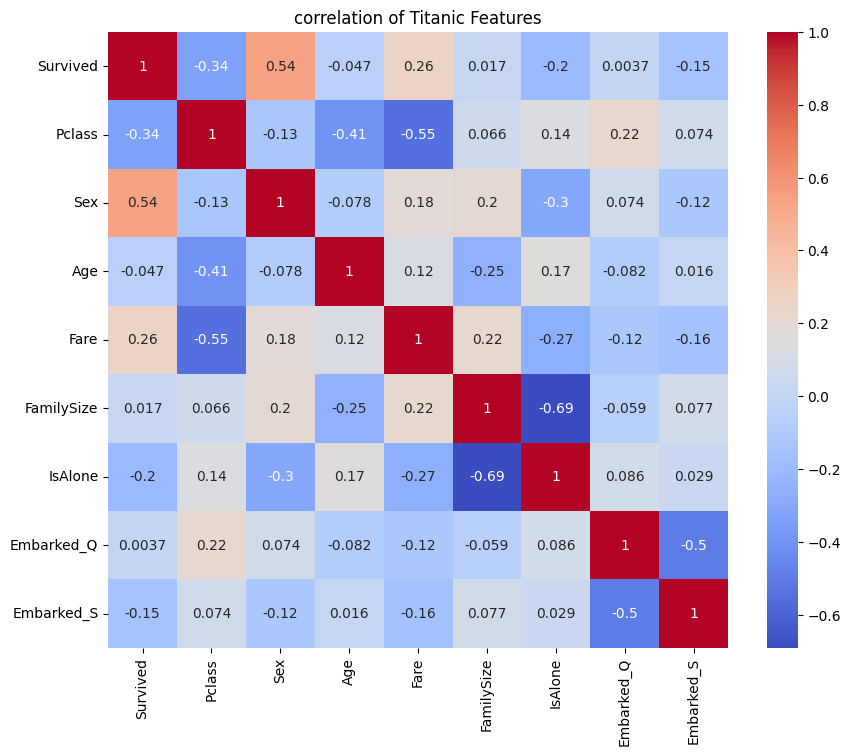

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)
plt.title("correlation of Titanic Features")
plt.show()

### Survival Rate by Gender

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1292\737336186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Sex'].map({0:'Male',1:'Female'}),y='Survived',data=df,palette= 'magma')


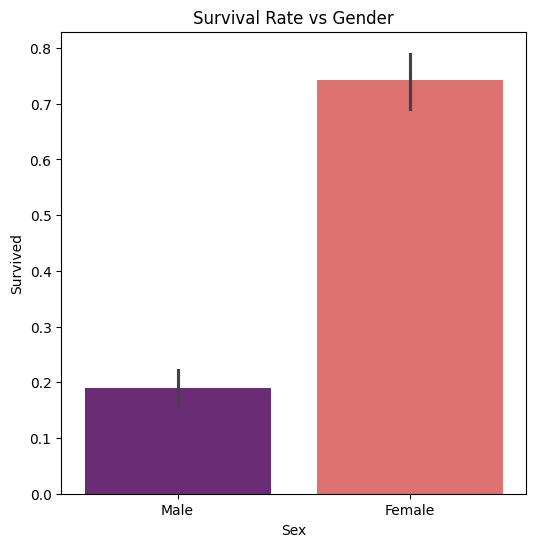

In [14]:
plt.figure(figsize=(6,6))
sns.barplot(x=df['Sex'].map({0:'Male',1:'Female'}),y='Survived',data=df,palette= 'magma')
plt.title("Survival Rate vs Gender")
plt.show()

### Survival Rate by Family Size

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1292\834871725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize',y='Survived',data=df,palette='viridis')


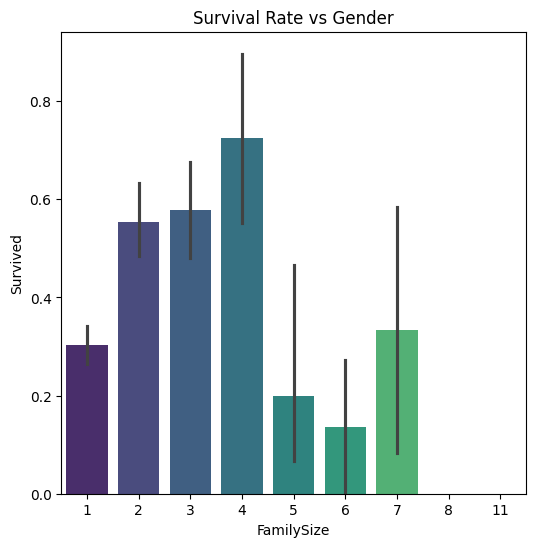

In [15]:
plt.figure(figsize=(6,6))
sns.barplot(x='FamilySize',y='Survived',data=df,palette='viridis')
plt.title("Survival Rate vs Gender")
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#split data into Features andf target 
x = df.drop(columns=['Survived'])
y = df['Survived']

# create training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

#initialize and train the model
model = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=5,min_samples_split=5,min_samples_leaf=2)
#min_samples_split =minimum number of samples required in a node before the tree is allowed to split it further
#min_samples_leaf → controls minimum samples in final leaf node
model.fit(x_train,y_train)
train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train,train_pred)
#predict and check accuracy
prediction = model.predict(x_test)

accuracy = accuracy_score(y_test,prediction)

print(f"Training accuracy: {train_accuracy*100:.2f}")
print(f"Test Accuracy: {accuracy*100:.2f}")



Training accuracy: 85.67
Test Accuracy: 82.12


### Feature Importance

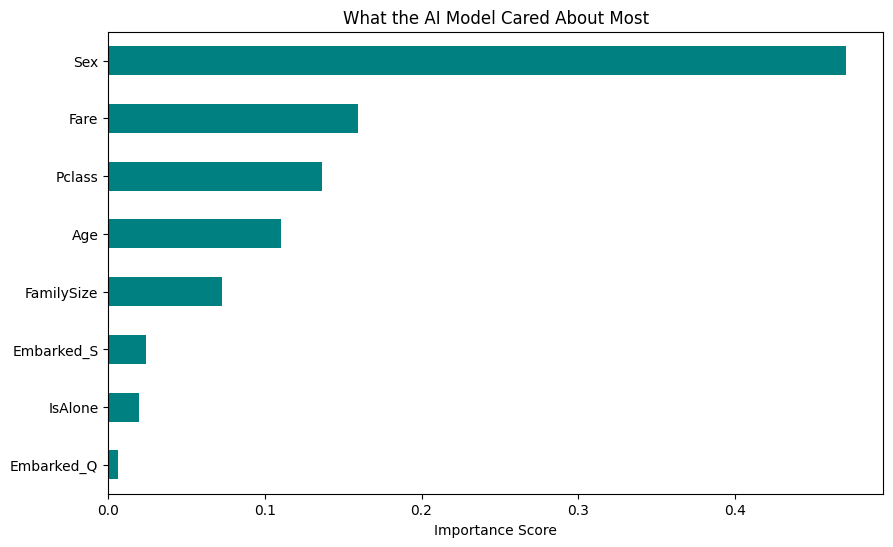

In [ ]:
importances = pd.Series(model.feature_importances_,index=x.columns)
#model.feature_importances_→ gives an array of importance values from RandomForest
#index=x.columns→ assigns each importance score to its corresponding column name.
importances.sort_values().plot(kind='barh',color='teal',figsize=(10,6))
plt.title("What the AI Model Cared About Most")
plt.xlabel("Importance Score")
plt.show()

--Classification Report--
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



<function matplotlib.pyplot.show(close=None, block=None)>

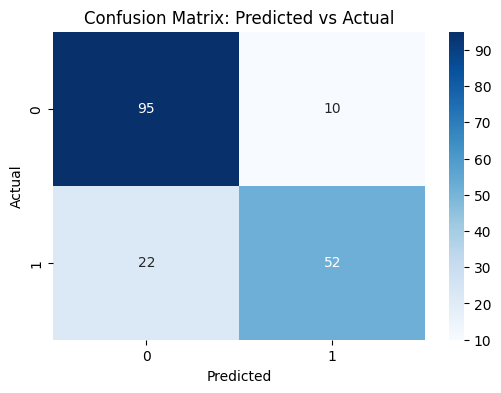

In [39]:
from sklearn.metrics import classification_report,confusion_matrix
#detailed report
print("--Classification Report--")
print(classification_report(y_test,prediction))

#Comfusion Matrix
cm = confusion_matrix(y_test,prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix: Predicted vs Actual")
plt.show